# 🚚 AI Hackathon: Route Optimization 2026 — Generalized CVRP Solver

**ทีม** เทสเทสหนึ่งสองสามสี่

Notebook นี้เป็น **ไฟล์เดียวที่รวมทุกอย่าง** — โค้ด Solver ทั้งหมดเขียนอยู่ในเซลล์ด้านล่าง ไม่ต้อง import ไฟล์อื่น  
กด **Runtime → Run all** ได้ทันที

| ส่วน | เนื้อหา |
|---|---|
| **ส่วนที่ 0** | เตรียมเครื่องมือ + โหลดข้อมูล |
| **ส่วนที่ 1 — Mission 2** | สร้าง Generalized CVRP Solver ทีละขั้น แล้วรันกับ A-n32-k5 / B-n31-k5 / P-n40-k5 |
| **ส่วนที่ 2 — Mission 3** | นำ Solver เดิมไปแก้โจทย์ CPAC Ready-Mix Concrete ที่มีข้อจำกัด "ความสดของคอนกรีต" |
| **ส่วนที่ 3** | สรุปผลและสมมติฐาน |

**ผลลัพธ์โดยย่อ**
- Mission 2: Feasible ครบทั้ง 3 ไฟล์ — Gap 5.48% / 0.74% / 12.23%
- Mission 3: **247 กม. ใช้รถ 7 จาก 8 คัน = เท่ากับคำตอบที่ดีที่สุด (Gap 0.00%)** และสั้นกว่าวิธีพื้นฐาน (Nearest Neighbor) 16.6%

---
# เตรียมเครื่องมือและข้อมูล

### 0.1 Import ไลบรารี
ใช้แค่ไลบรารีพื้นฐานของ Python + `matplotlib` สำหรับวาดกราฟ ไม่ต้องติดตั้งอะไรเพิ่ม

In [1]:
import math
import os
import re
import itertools
from dataclasses import dataclass, field
from functools import lru_cache
from typing import Callable, Dict, List, Optional, Tuple

import matplotlib.pyplot as plt

# ชนิดข้อมูลที่ใช้บ่อย (ช่วยให้อ่านโค้ดง่ายขึ้น)
Route = List[int]                        # เส้นทาง 1 คัน เช่น [1, 5, 3, 1]  (1 = คลัง)
DistMatrix = Dict[Tuple[int, int], int]  # ระยะทางระหว่างทุกคู่จุด
RouteCheck = Callable[[Route], bool]     # ฟังก์ชันตรวจว่าเส้นทางถูกกติกาไหม

print("พร้อมใช้งาน ✔")

พร้อมใช้งาน ✔


### 0.2 โหลดไฟล์ข้อมูล (รูปแบบ VRPLIB)

- **บน Google Colab:** จะมีปุ่มให้อัปโหลดไฟล์ (เลือกได้หลายไฟล์พร้อมกัน) — ใช้ทดสอบกับไฟล์ใหม่ๆ ได้ทุกไฟล์
- **ถ้าไม่อัปโหลด / กด Cancel:** notebook จะสร้างไฟล์ข้อมูล 4 ไฟล์ของโจทย์นี้ให้เองจากข้อความด้านล่าง เพื่อให้รันได้ทันที

> ข้อความด้านล่างเป็น **ข้อมูลโจทย์** (พิกัด, demand, ความจุ) เท่านั้น — **ไม่มีคำตอบหรือเส้นทางใดๆ ถูกเขียนไว้ล่วงหน้า**

In [2]:
# ข้อมูลโจทย์ในรูปแบบ VRPLIB (ข้อความเดียวกับไฟล์ .txt ที่ส่งมาด้วย)
DATASETS = {
    'A-n32-k5.txt': '''NAME : A-n32-k5
COMMENT : (Augerat et al, No of trucks: 5, Optimal value: 784)
TYPE : CVRP
DIMENSION : 32
EDGE_WEIGHT_TYPE : EUC_2D 
CAPACITY : 100
NODE_COORD_SECTION 
 1 82 76
 2 96 44
 3 50 5
 4 49 8
 5 13 7
 6 29 89
 7 58 30
 8 84 39
 9 14 24
 10 2 39
 11 3 82
 12 5 10
 13 98 52
 14 84 25
 15 61 59
 16 1 65
 17 88 51
 18 91 2
 19 19 32
 20 93 3
 21 50 93
 22 98 14
 23 5 42
 24 42 9
 25 61 62
 26 9 97
 27 80 55
 28 57 69
 29 23 15
 30 20 70
 31 85 60
 32 98 5
DEMAND_SECTION 
1 0 
2 19 
3 21 
4 6 
5 19 
6 7 
7 12 
8 16 
9 6 
10 16 
11 8 
12 14 
13 21 
14 16 
15 3 
16 22 
17 18 
18 19 
19 1 
20 24 
21 8 
22 12 
23 4 
24 8 
25 24 
26 24 
27 2 
28 20 
29 15 
30 2 
31 14 
32 9 
DEPOT_SECTION 
 1  
 -1  
EOF 
''',
    'B-n31-k5.txt': '''NAME : B-n31-k5
COMMENT : (Augerat et al, No of trucks: 5, Optimal value: 672)
TYPE : CVRP
DIMENSION : 31
EDGE_WEIGHT_TYPE : EUC_2D 
CAPACITY : 100
NODE_COORD_SECTION 
 1 17 76
 2 24 6
 3 96 29
 4 14 19
 5 14 32
 6 0 34
 7 16 22
 8 20 26
 9 22 28
 10 17 23
 11 98 30
 12 30 8
 13 23 27
 14 19 23
 15 34 7
 16 31 7
 17 0 37
 18 19 23
 19 0 36
 20 26 7
 21 98 32
 22 5 40
 23 17 26
 24 21 26
 25 28 8
 26 1 35
 27 27 28
 28 99 30
 29 26 28
 30 17 29
 31 20 26
DEMAND_SECTION 
1 0 
2 25 
3 3 
4 13 
5 17 
6 16 
7 9 
8 22 
9 10 
10 16 
11 8 
12 3 
13 16 
14 16 
15 10 
16 24 
17 16 
18 15 
19 14 
20 5 
21 12 
22 2 
23 18 
24 20 
25 15 
26 8 
27 22 
28 15 
29 10 
30 13 
31 19 
DEPOT_SECTION 
 1  
 -1  
EOF 
''',
    'P-n40-k5.txt': '''NAME : P-n40-k5
COMMENT : (Augerat et al, No of trucks: 5, Optimal value: 458)
TYPE : CVRP
DIMENSION : 40
EDGE_WEIGHT_TYPE : EUC_2D
CAPACITY : 140
NODE_COORD_SECTION
1 30 40
2 37 52
3 49 49
4 52 64
5 20 26
6 40 30
7 21 47
8 17 63
9 31 62
10 52 33
11 51 21
12 42 41
13 31 32
14 5 25
15 12 42
16 36 16
17 52 41
18 27 23
19 17 33
20 13 13
21 57 58
22 62 42
23 42 57
24 16 57
25 8 52
26 7 38
27 27 68
28 30 48
29 43 67
30 58 48
31 58 27
32 37 69
33 38 46
34 46 10
35 61 33
36 62 63
37 63 69
38 32 22
39 45 35
40 59 15
DEMAND_SECTION
1 0
2 7
3 30
4 16
5 9
6 21
7 15
8 19
9 23
10 11
11 5
12 19
13 29
14 23
15 21
16 10
17 15
18 3
19 41
20 9
21 28
22 8
23 8
24 16
25 10
26 28
27 7
28 15
29 14
30 6
31 19
32 11
33 12
34 23
35 26
36 17
37 6
38 9
39 15
40 14
DEPOT_SECTION
 1
 -1
EOF
''',
    'CPAC-n16-k8-fresh.txt': '''NAME : CPAC-n16-k8-fresh
COMMENT : (Self-created Case, SCG-CPAC Ready-Mix Concrete Delivery, No of trucks: 8)
TYPE : CVRP
DIMENSION : 16
EDGE_WEIGHT_TYPE : EUC_2D
CAPACITY : 10
FRESHNESS_LIMIT_MIN : 90
SPEED_KMH : 30
SERVICE_TIME_MIN : 10
NODE_COORD_SECTION
1 20 20
2 14 7
3 25 5
4 21 15
5 4 20
6 3 18
7 5 5
8 17 32
9 6 10
10 25 36
11 23 16
12 37 4
13 33 12
14 7 6
15 13 31
16 9 23
DEMAND_SECTION
1 0
2 4
3 4
4 6
5 4
6 4
7 4
8 3
9 4
10 5
11 5
12 2
13 3
14 2
15 5
16 5
DEPOT_SECTION
1
-1
EOF
''',
}

try:
    from google.colab import files as colab_files
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

data_files = []
if IN_COLAB:
    print("เลือกไฟล์ข้อมูล (.txt / .vrp) — หรือกด Cancel เพื่อใช้ข้อมูลในตัว notebook")
    try:
        data_files = sorted(colab_files.upload().keys())
    except Exception:
        data_files = []

if not data_files:                     # ใช้ข้อมูลที่ฝังไว้ใน notebook
    for name, text in DATASETS.items():
        with open(name, "w", encoding="utf-8") as f:
            f.write(text)
    data_files = sorted(DATASETS)

# แยกไฟล์: ไฟล์ที่มีข้อจำกัดความสด (ชื่อมีคำว่า fresh) ใช้ใน Mission 3 ที่เหลือใช้ใน Mission 2
benchmark_files = [f for f in data_files if "fresh" not in f.lower()]
case_file = next((f for f in data_files if "fresh" in f.lower()), None)
print("Mission 2 (benchmark):", benchmark_files)
print("Mission 3 (CPAC case):", case_file)

Mission 2 (benchmark): ['A-n32-k5.txt', 'B-n31-k5.txt', 'P-n40-k5.txt']
Mission 3 (CPAC case): CPAC-n16-k8-fresh.txt


---
# Mission 2: Generalized CVRP Solver

**CVRP คืออะไร** — รถหลายคันออกจากคลัง ไปส่งของให้ลูกค้าทุกจุด แล้วกลับคลัง โดยห้ามบรรทุกเกินความจุ และต้องใช้ระยะทางรวมน้อยที่สุด

**หลักการของทีม:** Solver **ชุดเดียว** ใช้กับทุกไฟล์ — ไม่มีการเขียนเส้นทางตายตัวของไฟล์ใดไฟล์หนึ่ง เปลี่ยนแค่ไฟล์ข้อมูลที่ใส่เข้าไป

```
อ่านไฟล์ → คำนวณระยะทาง → สร้างเส้นทางเริ่มต้น (Clarke-Wright) → ปรับปรุง (Relocate / Swap / 2-opt) → ตรวจกติกา → คำนวณ Gap
```

### 1.1 โครงสร้างข้อมูล
- `VRPInstance` = ข้อมูลโจทย์ 1 ไฟล์
- `SolverResult` = ผลลัพธ์ 1 ไฟล์ (ใช้พิมพ์ Result Card)

In [3]:
@dataclass
class VRPInstance:
    name: str
    dimension: int
    capacity: int                                   # ความจุรถต่อคัน
    coords: Dict[int, Tuple[float, float]]          # จุดที่ -> (x, y)
    demands: Dict[int, int]                         # จุดที่ -> ปริมาณที่ต้องส่ง
    depot_id: int                                   # จุดที่เป็นคลัง
    num_vehicles: Optional[int] = None              # จำนวนรถสูงสุดที่ใช้ได้
    optimal_value: Optional[float] = None           # ค่า Optimal ที่ตีพิมพ์ (ถ้ามี)

    @property
    def customer_ids(self) -> List[int]:
        return [n for n in self.coords if n != self.depot_id]


@dataclass
class SolverResult:
    instance_name: str
    routes: List[Route]
    route_loads: List[int]
    total_distance: int
    feasible: bool
    feasibility_report: List[str]
    optimal_value: Optional[float]
    gap_percent: Optional[float]
    num_vehicles_used: int
    algorithm: str = "Clarke-Wright Savings + Relocate + Swap + 2-opt"

### 1.2 อ่านไฟล์ VRPLIB (Parser)
อ่านหัวไฟล์ (`NAME`, `CAPACITY`, `COMMENT`) และ 3 ส่วนข้อมูล (`NODE_COORD_SECTION`, `DEMAND_SECTION`, `DEPOT_SECTION`)  
จำนวนรถและค่า Optimal อ่านจาก `COMMENT` เช่น `(... No of trucks: 5, Optimal value: 784)` ถ้าไม่มีจะอ่านจากชื่อไฟล์ `-k5`

In [4]:
def parse_vrp_file(filepath: str) -> VRPInstance:
    name, dimension, capacity = "", 0, 0
    num_vehicles = optimal_value = None
    coords, demands = {}, {}
    depot_id, section = 1, None

    with open(filepath, "r", encoding="utf-8", errors="ignore") as f:
        lines = [line.strip() for line in f]

    for raw in lines:
        if not raw:
            continue
        upper = raw.upper()

        # --- บรรทัดหัวไฟล์แบบ  KEY : VALUE ---
        if ":" in raw and not upper.startswith(("NODE_COORD_SECTION", "DEMAND_SECTION", "DEPOT_SECTION")):
            key, _, value = raw.partition(":")
            key, value = key.strip().upper(), value.strip()
            if key == "NAME":
                name = value
            elif key == "DIMENSION":
                dimension = int(value)
            elif key == "CAPACITY":
                capacity = int(value)
            elif key == "COMMENT":
                m = re.search(r"No of trucks:\s*(\d+)", value, re.I)
                if m:
                    num_vehicles = int(m.group(1))
                m = re.search(r"Optimal value:\s*([\d.]+)", value, re.I)
                if m:
                    optimal_value = float(m.group(1))
            continue

        # --- เปลี่ยนส่วนของไฟล์ ---
        if upper.startswith("NODE_COORD_SECTION"): section = "COORD"; continue
        if upper.startswith("DEMAND_SECTION"):     section = "DEMAND"; continue
        if upper.startswith("DEPOT_SECTION"):      section = "DEPOT"; continue
        if upper.startswith("EOF"):                break

        # --- ข้อมูลในแต่ละส่วน ---
        parts = raw.split()
        if section == "COORD" and len(parts) >= 3:
            coords[int(parts[0])] = (float(parts[1]), float(parts[2]))
        elif section == "DEMAND" and len(parts) >= 2:
            demands[int(parts[0])] = int(float(parts[1]))
        elif section == "DEPOT" and parts and int(parts[0]) != -1:
            depot_id = int(parts[0])

    if not name:
        name = os.path.splitext(os.path.basename(filepath))[0]
    if num_vehicles is None:                       # ใช้ชื่อไฟล์ "...-kN"
        m = re.search(r"-k(\d+)", name, re.I)
        if m:
            num_vehicles = int(m.group(1))

    return VRPInstance(name, dimension or len(coords), capacity, coords, demands,
                       depot_id, num_vehicles, optimal_value)


# ทดลองอ่านไฟล์แรก
_test = parse_vrp_file(benchmark_files[0])
print(f"{_test.name}: ลูกค้า {len(_test.customer_ids)} จุด, ความจุ {_test.capacity}, "
      f"รถ {_test.num_vehicles} คัน, Optimal = {_test.optimal_value}")

A-n32-k5: ลูกค้า 31 จุด, ความจุ 100, รถ 5 คัน, Optimal = 784.0


### 1.3 คำนวณระยะทาง (EUC_2D)
ตามมาตรฐาน TSPLIB: ระยะเส้นตรง (Euclidean) แล้ว **ปัดเป็นจำนวนเต็มที่ใกล้ที่สุด** — ค่า Optimal ที่ตีพิมพ์ก็คำนวณแบบนี้ จึงเทียบกันได้ตรงๆ

In [5]:
def euc_2d_round(p1, p2) -> int:
    return math.floor(math.hypot(p1[0] - p2[0], p1[1] - p2[1]) + 0.5)


def build_distance_matrix(inst: VRPInstance) -> DistMatrix:
    ids = list(inst.coords)
    return {(i, j): 0 if i == j else euc_2d_round(inst.coords[i], inst.coords[j])
            for i in ids for j in ids}


def route_length(route: Route, dist: DistMatrix) -> int:
    return sum(dist[(route[k], route[k + 1])] for k in range(len(route) - 1))


def total_length(routes: List[Route], dist: DistMatrix) -> int:
    return sum(route_length(r, dist) for r in routes)


def route_load(route: Route, inst: VRPInstance) -> int:
    return sum(inst.demands.get(c, 0) for c in route[1:-1])

### 1.4 กติกาของเส้นทาง — `route_ok` (หัวใจของการ "ใช้ได้กับหลายโจทย์")

ทุกขั้นตอนที่สร้างหรือแก้เส้นทาง จะ **ถามฟังก์ชัน `route_ok(route)`** ก่อนเสมอว่า "เส้นทางใหม่นี้ถูกกติกาไหม"

- Mission 2 ใช้ `route_ok` ที่ตรวจแค่ **ความจุ**
- Mission 3 แค่ส่ง `route_ok` ตัวใหม่ที่ตรวจ **ความจุ + เวลา** เข้าไป — **ไม่ต้องแก้โค้ด Solver เลย**

In [6]:
def capacity_check(inst: VRPInstance) -> RouteCheck:
    """กติกาพื้นฐานของ CVRP: ของบนรถต้องไม่เกินความจุ"""
    return lambda route: route_load(route, inst) <= inst.capacity

### 1.5 สร้างเส้นทางเริ่มต้น — Clarke & Wright Savings

แนวคิด: เริ่มจาก "ลูกค้า 1 จุด = รถ 1 คัน" แล้วค่อยๆ **รวมเส้นทาง** คู่ที่ประหยัดระยะทางได้มากที่สุดก่อน

**ค่าประหยัด (saving)** ของการรวมลูกค้า i กับ j:  `s(i,j) = d(คลัง,i) + d(คลัง,j) − d(i,j)`

รวมได้ก็ต่อเมื่อ i และ j อยู่ปลายเส้นทาง (ติดคลัง) และเส้นทางใหม่ยังผ่าน `route_ok`

In [7]:
def clarke_wright_savings(inst: VRPInstance, dist: DistMatrix, route_ok: RouteCheck) -> List[Route]:
    depot, customers = inst.depot_id, inst.customer_ids
    routes = {c: [depot, c, depot] for c in customers}   # เริ่ม: 1 ลูกค้า = 1 คัน
    route_of = {c: c for c in customers}                  # ลูกค้าคนนี้อยู่เส้นทางไหน

    # คำนวณ saving ทุกคู่ แล้วเรียงจากมากไปน้อย
    savings = [(dist[(depot, i)] + dist[(depot, j)] - dist[(i, j)], i, j)
               for a, i in enumerate(customers) for j in customers[a + 1:]]
    savings.sort(key=lambda t: t[0], reverse=True)

    for s, i, j in savings:
        if s <= 0:
            continue
        ri, rj = route_of[i], route_of[j]
        if ri == rj:
            continue                                        # อยู่คันเดียวกันแล้ว
        route_i, route_j = routes[ri], routes[rj]
        if i not in (route_i[1], route_i[-2]) or j not in (route_j[1], route_j[-2]):
            continue                                        # i หรือ j ไม่ได้อยู่ปลายเส้นทาง
        seg_i = route_i[1:-1] if route_i[-2] == i else route_i[1:-1][::-1]   # ให้ i อยู่ท้าย
        seg_j = route_j[1:-1] if route_j[1] == j else route_j[1:-1][::-1]    # ให้ j อยู่หน้า
        merged = [depot] + seg_i + seg_j + [depot]
        if not route_ok(merged):
            continue
        routes[ri] = merged
        for c in merged[1:-1]:
            route_of[c] = ri
        del routes[rj]

    return list(routes.values())

### 1.6 ปรับปรุงเส้นทาง (Local Search)

| Move | ทำอะไร |
|---|---|
| **Relocate** | ย้ายลูกค้า 1 จุด ไปตำแหน่งที่ดีที่สุดในรถคันอื่น — ถ้ารถคันเดิมว่าง ให้ **ยุบรถคันนั้นทิ้ง** |
| **Swap** | สลับลูกค้า 1 คู่ระหว่างรถ 2 คัน |
| **2-opt** | กลับลำดับช่วงหนึ่งในเส้นทาง เพื่อ **ลบเส้นที่วิ่งไขว้กัน** ในรถคันเดียวกัน |

รับเฉพาะการเปลี่ยนแปลงที่ **ระยะรวมสั้นลง และผ่าน `route_ok`** แล้ววนทั้ง 3 move ซ้ำจนไม่มีอะไรดีขึ้นอีก

In [8]:
def two_opt(route: Route, dist: DistMatrix, route_ok: Optional[RouteCheck] = None) -> Route:
    """กลับลำดับช่วง a..b ถ้าเส้นทางสั้นลง (ลบเส้นไขว้ในคันเดียวกัน)"""
    best, best_len = route[:], route_length(route, dist)
    improved = True
    while improved:
        improved = False
        for a in range(1, len(best) - 2):
            for b in range(a + 1, len(best) - 1):
                cand = best[:a] + best[a:b + 1][::-1] + best[b + 1:]
                cand_len = route_length(cand, dist)
                if cand_len < best_len and (route_ok is None or route_ok(cand)):
                    best, best_len, improved = cand, cand_len, True
    return best


def relocate(routes: List[Route], dist: DistMatrix, route_ok: RouteCheck) -> List[Route]:
    """ย้ายลูกค้า 1 จุดไปรถคันอื่น ถ้าระยะรวมลดลง (รถที่ว่างจะถูกยุบ)"""
    routes = [r[:] for r in routes]
    improved = True
    while improved:
        improved = False
        for i, r_from in enumerate(routes):
            for pos in range(1, len(r_from) - 1):
                cust = r_from[pos]
                new_from = r_from[:pos] + r_from[pos + 1:]
                # ระยะที่ประหยัดได้เมื่อดึงลูกค้าออก (ถ้ารถว่าง = ประหยัดทั้งเส้น)
                gain = route_length(r_from, dist) - (route_length(new_from, dist) if len(new_from) > 2 else 0)
                best = None
                for j, r_to in enumerate(routes):
                    if j == i:
                        continue
                    for k in range(len(r_to) - 1):
                        add = dist[(r_to[k], cust)] + dist[(cust, r_to[k + 1])] - dist[(r_to[k], r_to[k + 1])]
                        delta = gain - add
                        if delta > 0 and (best is None or delta > best[0]):
                            cand = r_to[:k + 1] + [cust] + r_to[k + 1:]
                            if route_ok(cand) and (len(new_from) <= 2 or route_ok(new_from)):
                                best = (delta, j, cand)
                if best:
                    _, j, cand = best
                    routes[j], routes[i] = cand, new_from
                    routes = [r for r in routes if len(r) > 2]   # ลบรถที่ว่าง
                    improved = True
                    break
            if improved:
                break
    return routes


def swap_customers(routes: List[Route], dist: DistMatrix, route_ok: RouteCheck) -> List[Route]:
    """สลับลูกค้า 1 คู่ระหว่างรถ 2 คัน ถ้าระยะรวมลดลง"""
    routes = [r[:] for r in routes]
    improved = True
    while improved:
        improved = False
        for i in range(len(routes)):
            for j in range(i + 1, len(routes)):
                r_i, r_j = routes[i], routes[j]
                for pi in range(1, len(r_i) - 1):
                    for pj in range(1, len(r_j) - 1):
                        ci, cj = r_i[pi], r_j[pj]
                        old = (dist[(r_i[pi - 1], ci)] + dist[(ci, r_i[pi + 1])]
                               + dist[(r_j[pj - 1], cj)] + dist[(cj, r_j[pj + 1])])
                        new = (dist[(r_i[pi - 1], cj)] + dist[(cj, r_i[pi + 1])]
                               + dist[(r_j[pj - 1], ci)] + dist[(ci, r_j[pj + 1])])
                        if new >= old:
                            continue
                        ni = r_i[:pi] + [cj] + r_i[pi + 1:]
                        nj = r_j[:pj] + [ci] + r_j[pj + 1:]
                        if route_ok(ni) and route_ok(nj):
                            routes[i], routes[j] = ni, nj
                            r_i, r_j = ni, nj
                            improved = True
    return routes


def improve(routes: List[Route], dist: DistMatrix, route_ok: RouteCheck, max_rounds: int = 50) -> List[Route]:
    """วน Relocate -> Swap -> 2-opt จนระยะรวมไม่ลดลงอีก"""
    best = total_length(routes, dist)
    for _ in range(max_rounds):
        routes = relocate(routes, dist, route_ok)
        routes = swap_customers(routes, dist, route_ok)
        routes = [two_opt(r, dist, route_ok) for r in routes]
        current = total_length(routes, dist)
        if current >= best:
            break
        best = current
    return routes

### 1.7 ตรวจกติกา (Feasibility = ด่านแรก) และคำนวณ Gap

ตรวจ **แยกจากขั้นตอนสร้างเส้นทาง** เพื่อยืนยันว่าคำตอบถูกต้องจริง ก่อนนำระยะทางไปเทียบ

1. **Node Coverage** — ลูกค้าทุกจุดได้รับของ
2. **Visited once** — ไม่มีลูกค้าถูกเยี่ยมซ้ำ
3. **Capacity** — ไม่มีรถคันไหนบรรทุกเกิน
4. **Fleet Limit** — ใช้รถไม่เกินจำนวนที่มี
5. **Depot Routing** — ทุกเส้นทางเริ่มและจบที่คลัง

$$\text{Gap (\%)} = \frac{\text{ระยะของทีม} - \text{Optimal}}{\text{Optimal}} \times 100$$

In [9]:
def check_feasibility(inst: VRPInstance, routes: List[Route]) -> Tuple[bool, List[str]]:
    report, ok = [], True
    visited = [c for r in routes for c in r[1:-1]]
    missing = set(inst.customer_ids) - set(visited)
    duplicated = sorted({c for c in visited if visited.count(c) > 1})
    over = [(k + 1, route_load(r, inst)) for k, r in enumerate(routes) if route_load(r, inst) > inst.capacity]
    bad_depot = [k + 1 for k, r in enumerate(routes) if r[0] != inst.depot_id or r[-1] != inst.depot_id]
    too_many = inst.num_vehicles is not None and len(routes) > inst.num_vehicles

    checks = [
        (not missing,    "Node Coverage",  "all customers are visited" if not missing else f"missing {sorted(missing)}"),
        (not duplicated, "Visited-once",   "no customer appears twice" if not duplicated else f"repeated {duplicated}"),
        (not over,       "Capacity",       f"all routes <= {inst.capacity}" if not over else f"over capacity {over}"),
        (not too_many,   "Fleet Limit",    f"used {len(routes)}" + (f" / max {inst.num_vehicles}" if inst.num_vehicles else "")),
        (not bad_depot,  "Depot Routing",  "every route starts and ends at the depot" if not bad_depot else f"bad routes {bad_depot}"),
    ]
    for passed, rule, detail in checks:
        ok &= passed
        report.append(f"{'PASS' if passed else 'FAIL'} - {rule}: {detail}")
    return ok, report


def compute_gap(team_cost: float, optimal_cost: Optional[float]) -> Optional[float]:
    if not optimal_cost:
        return None
    return (team_cost - optimal_cost) / optimal_cost * 100.0

### 1.8 รวมทุกขั้นเป็น Solver ตัวเดียว — `solve(ไฟล์)`
และฟังก์ชันแสดงผล **Result Card** + **แผนที่เส้นทาง**

In [10]:
def solve(filepath: str):
    """Solver ของ Mission 2: ใช้ฟังก์ชันเดียวกันกับทุกไฟล์"""
    inst = parse_vrp_file(filepath)
    dist = build_distance_matrix(inst)
    rule = capacity_check(inst)

    routes = clarke_wright_savings(inst, dist, rule)   # 1) สร้างเส้นทางเริ่มต้น
    routes = improve(routes, dist, rule)                # 2) ปรับปรุง

    total = total_length(routes, dist)                  # 3) ตรวจผล + Gap
    feasible, report = check_feasibility(inst, routes)
    result = SolverResult(inst.name, routes, [route_load(r, inst) for r in routes], total,
                          feasible, report, inst.optimal_value,
                          compute_gap(total, inst.optimal_value), len(routes))
    return result, inst


def print_result_card(res: SolverResult):
    print("=" * 64)
    print(f"RESULT CARD - {res.instance_name}")
    print("=" * 64)
    print(f"Algorithm : {res.algorithm}\n")
    for k, (r, load) in enumerate(zip(res.routes, res.route_loads), 1):
        print(f"Route {k} (load={load}): " + " -> ".join(map(str, r)))
    print(f"\nTotal Distance : {res.total_distance}")
    if res.optimal_value is not None:
        print(f"Optimal (known): {res.optimal_value:g}")
        print(f"Gap            : {res.gap_percent:.2f}%")
    print(f"Feasible       : {'YES' if res.feasible else 'NO'}")
    print(f"Vehicles Used  : {res.num_vehicles_used}\n")
    print("Feasibility checklist:")
    for line in res.feasibility_report:
        print("  -", line)
    print("=" * 64 + "\n")


def plot_routes(inst: VRPInstance, routes: List[Route], title: str, ax):
    colors = plt.cm.tab10.colors
    for k, r in enumerate(routes):
        xs = [inst.coords[n][0] for n in r]
        ys = [inst.coords[n][1] for n in r]
        ax.plot(xs, ys, "-o", color=colors[k % 10], ms=4, lw=1.6, label=f"Truck {k + 1}")
    for n, (x, y) in inst.coords.items():
        if n != inst.depot_id:
            ax.annotate(str(n), (x, y), textcoords="offset points", xytext=(4, 4), fontsize=7)
    dx, dy = inst.coords[inst.depot_id]
    ax.scatter([dx], [dy], marker="s", s=120, c="black", zorder=5, label="Depot")
    ax.set_title(title, fontsize=11)
    ax.set_aspect("equal", adjustable="datalim")
    ax.grid(alpha=0.25)
    ax.legend(fontsize=7, loc="upper left", bbox_to_anchor=(1.01, 1.0), frameon=False)

### 1.9 ▶ รัน Mission 2 กับ Benchmark ทั้ง 3 ชุด

In [11]:
mission2 = []
for fp in benchmark_files:
    res, inst = solve(fp)
    print_result_card(res)
    mission2.append((res, inst))

print("SUMMARY — Mission 2")
print(f"{'Instance':<12}{'Vehicles':<10}{'Distance':<10}{'Optimal':<10}{'Gap %':<9}Feasible")
for r, _ in mission2:
    opt = f"{r.optimal_value:g}" if r.optimal_value else "-"
    gap = f"{r.gap_percent:.2f}" if r.gap_percent is not None else "-"
    print(f"{r.instance_name:<12}{r.num_vehicles_used:<10}{r.total_distance:<10}{opt:<10}{gap:<9}{'YES' if r.feasible else 'NO'}")

RESULT CARD - A-n32-k5
Algorithm : Clarke-Wright Savings + Relocate + Swap + 2-opt

Route 1 (load=90): 1 -> 13 -> 2 -> 14 -> 8 -> 17 -> 1
Route 2 (load=93): 1 -> 27 -> 4 -> 3 -> 18 -> 20 -> 32 -> 22 -> 1
Route 3 (load=98): 1 -> 15 -> 19 -> 23 -> 10 -> 9 -> 12 -> 5 -> 29 -> 24 -> 7 -> 1
Route 4 (load=38): 1 -> 25 -> 31 -> 1
Route 5 (load=91): 1 -> 28 -> 30 -> 16 -> 11 -> 26 -> 6 -> 21 -> 1

Total Distance : 827
Optimal (known): 784
Gap            : 5.48%
Feasible       : YES
Vehicles Used  : 5

Feasibility checklist:
  - PASS - Node Coverage: all customers are visited
  - PASS - Visited-once: no customer appears twice
  - PASS - Capacity: all routes <= 100
  - PASS - Fleet Limit: used 5 / max 5
  - PASS - Depot Routing: every route starts and ends at the depot

RESULT CARD - B-n31-k5
Algorithm : Clarke-Wright Savings + Relocate + Swap + 2-opt

Route 1 (load=70): 1 -> 21 -> 28 -> 11 -> 3 -> 27 -> 29 -> 1
Route 2 (load=94): 1 -> 5 -> 30 -> 23 -> 24 -> 13 -> 9 -> 1
Route 3 (load=97): 1 -> 

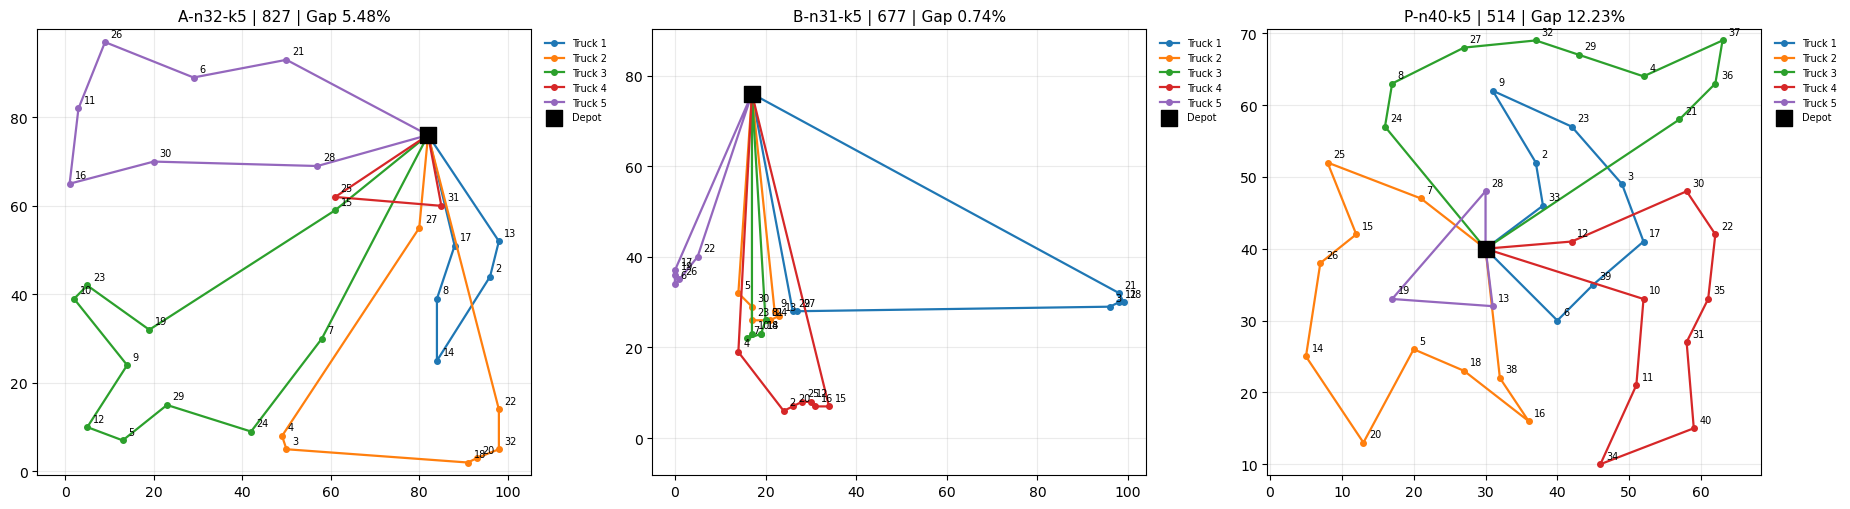

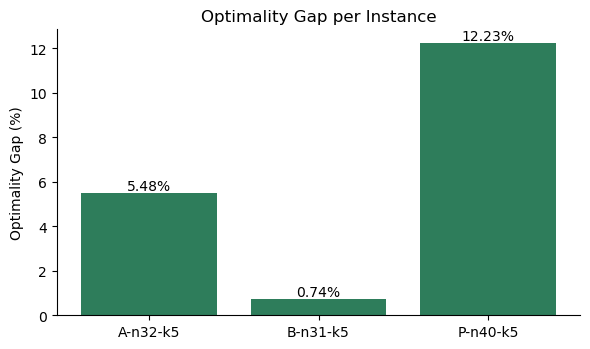

In [12]:
# แผนที่เส้นทาง: สีเดียวกัน = รถคันเดียวกัน, สี่เหลี่ยมดำ = คลัง
fig, axes = plt.subplots(1, len(mission2), figsize=(6.2 * len(mission2), 5.2))
axes = axes if len(mission2) > 1 else [axes]
for ax, (r, inst) in zip(axes, mission2):
    gap = f" | Gap {r.gap_percent:.2f}%" if r.gap_percent is not None else ""
    plot_routes(inst, r.routes, f"{r.instance_name} | {r.total_distance}{gap}", ax)
fig.tight_layout()
plt.show()

# กราฟ Gap ของแต่ละไฟล์
with_opt = [(r.instance_name, r.gap_percent) for r, _ in mission2 if r.gap_percent is not None]
fig, ax = plt.subplots(figsize=(6, 3.6))
bars = ax.bar([n for n, _ in with_opt], [g for _, g in with_opt], color="#2E7D5B")
ax.bar_label(bars, labels=[f"{g:.2f}%" for _, g in with_opt])
ax.set_ylabel("Optimality Gap (%)")
ax.set_title("Optimality Gap per Instance")
ax.spines[["top", "right"]].set_visible(False)
fig.tight_layout()
plt.show()

**อ่านผล Mission 2**
- ทั้ง 3 ไฟล์ **Feasible** ผ่านครบ 5 กติกา
- B-n31-k5 ใกล้ Optimal มาก (0.74%) ส่วน P-n40-k5 Gap สูงสุด (12.23%) เพราะความจุตึงและลูกค้ากระจาย ทำให้การย้ายทีละจุดติด "หลุมคำตอบ" ได้ง่าย
- ในแผนที่ยังเห็น **เส้นไขว้ระหว่างรถต่างคัน** (2-opt แก้ได้แค่ในคันเดียว) → เป็นแนวทางพัฒนาต่อ

---
# Mission 3: CPAC Ready-Mix Concrete Delivery

### 2.1 โจทย์จากโลกจริง
คอนกรีตผสมเสร็จ **เริ่มแข็งตัวทันทีหลังผสม** ถ้ารถโม่งไปถึงไซต์ช้าเกินไป คอนกรีตจะเทไม่ได้และต้องทิ้งทั้งคัน

> ในหนึ่งรอบจ่ายงาน โรงงาน CPAC ต้องส่งคอนกรีตให้ **15 ไซต์** ด้วยรถโม่ง **10 ลบ.ม. × 8 คัน** จะจัดเส้นทางอย่างไรให้ส่งครบ ไม่เกินความจุ **ถึงทุกไซต์ภายใน 90 นาที** และใช้ระยะทางรวมน้อยที่สุด

| บริบทจริง | ในโมเดล |
|---|---|
| โรงงานผสม CPAC | Depot (จุดที่ 1) |
| ไซต์ก่อสร้าง 15 แห่ง | Customers (จุดที่ 2–16) |
| ปริมาณคอนกรีตที่สั่ง | Demand (2–6 ลบ.ม., รวม 60) |
| รถโม่ง 10 ลบ.ม. × 8 คัน | Capacity + Fleet Limit |
| **ต้องถึงไซต์ภายใน 90 นาที** | **Freshness constraint (กติกาใหม่ข้อ 6)** |
| ลดน้ำมันและ CO2 | Objective = ระยะทางรวมน้อยที่สุด |

ไฟล์ `CPAC-n16-k8-fresh.txt` ใช้รูปแบบ VRPLIB เดิม + เพิ่ม 3 บรรทัด: `FRESHNESS_LIMIT_MIN : 90`, `SPEED_KMH : 30`, `SERVICE_TIME_MIN : 10`  
*(พิกัดและ demand เป็นข้อมูลจำลองเพื่อการเรียนรู้ ไม่ใช่ข้อมูลจริงของ SCG)*

### 2.2 แบบจำลองเวลา + กติกาความสด

เวลาที่รถไปถึงไซต์ = ระยะทางสะสม ÷ 30 กม./ชม. + เวลาเท 10 นาที × จำนวนไซต์ที่แวะก่อนหน้า  
แล้วสร้าง `route_ok` ตัวใหม่ = **ความจุ + ทุกไซต์ถึงภายใน 90 นาที** — ส่งเข้าไปใน Solver เดิมได้เลย

In [13]:
def read_case_extensions(filepath: str):
    """อ่าน 3 ฟิลด์เสริมของ Mission 3 (ถ้าไฟล์ไม่มี จะได้ None = ไม่มีกติกาเวลา)"""
    limit = speed = None
    service = 0.0
    with open(filepath, "r", encoding="utf-8", errors="ignore") as f:
        for line in f:
            key, sep, value = line.partition(":")
            if not sep:
                continue
            key = key.strip().upper()
            if key == "FRESHNESS_LIMIT_MIN":
                limit = float(value)
            elif key == "SPEED_KMH":
                speed = float(value)
            elif key == "SERVICE_TIME_MIN":
                service = float(value)
    return limit, speed, service


def arrival_times(route: Route, dist: DistMatrix, speed_kmh: float, service_min: float) -> List[float]:
    """เวลา (นาทีหลังออกจากโรงงาน) ที่รถไปถึงแต่ละไซต์ในเส้นทาง"""
    t, out = 0.0, []
    for k in range(len(route) - 2):
        t += dist[(route[k], route[k + 1])] / speed_kmh * 60.0
        out.append(t)
        t += service_min                       # เวลาเทคอนกรีตก่อนไปไซต์ถัดไป
    return out


def freshness_check(inst, dist, limit, speed, service) -> RouteCheck:
    """route_ok ของ Mission 3 = ความจุ + ถึงทุกไซต์ภายใน limit นาที"""
    cap_ok = capacity_check(inst)
    def ok(route: Route) -> bool:
        if not cap_ok(route):
            return False
        at = arrival_times(route, dist, speed, service)
        return (max(at) if at else 0.0) <= limit + 1e-9
    return ok


def freshness_report(routes, dist, limit, speed, service):
    ok, report, worst = True, [], []
    for k, r in enumerate(routes, 1):
        at = arrival_times(r, dist, speed, service)
        w = max(at) if at else 0.0
        worst.append(w)
        passed = w <= limit + 1e-9
        ok &= passed
        report.append(f"{'PASS' if passed else 'FAIL'} - Freshness: Route {k} last arrival {w:.0f} min "
                      f"{'<=' if passed else '>'} {limit:.0f} min")
    return ok, report, worst

### 2.3 ซ่อมเส้นทางที่ไปถึงช้า (Repair)
ไล่ดูทีละเส้นทาง ถ้าไซต์ถัดไปจะถึงเกิน 90 นาที → **ตัดเส้นทางตรงนั้น** แล้วให้รถคันใหม่ออกจากโรงงานไปส่งไซต์ที่เหลือ

⚠️ การซ่อมอย่างเดียวทำให้คำตอบผ่านกติกา แต่ **อาจใช้รถเกินจำเป็น** — จึงต้องมีขั้นถัดไป (2.6)

In [14]:
def repair_split(routes: List[Route], depot: int, dist, limit, speed, service) -> List[Route]:
    out = []
    for r in routes:
        current, t = [depot], 0.0
        for c in r[1:-1]:
            arrive = t + dist[(current[-1], c)] / speed * 60.0
            if arrive > limit and len(current) > 1:      # จะถึงสาย -> ปิดคันนี้ เริ่มคันใหม่
                out.append(current + [depot])
                current, arrive = [depot], dist[(depot, c)] / speed * 60.0
            current.append(c)
            t = arrive + service
        out.append(current + [depot])
    return out

### 2.4 ไม้บรรทัดวัดคุณภาพ ① — วิธีพื้นฐาน Nearest Neighbor
"ไปจุดที่ใกล้ที่สุดที่ยังส่งได้ทันเวลาและรถยังไม่เต็ม" ทำซ้ำจนครบ — ใช้เป็น baseline ที่ทำตามกติกาเดียวกัน

In [15]:
def nearest_neighbour(inst: VRPInstance, dist: DistMatrix, route_ok: RouteCheck) -> List[Route]:
    depot, left, routes = inst.depot_id, set(inst.customer_ids), []
    while left:
        r = [depot]
        while True:
            options = sorted((dist[(r[-1], c)], c) for c in left if route_ok(r + [c, depot]))
            if not options:
                break
            r.append(options[0][1])
            left.remove(options[0][1])
        if len(r) == 1:
            raise ValueError("มีลูกค้าที่ส่งไม่ได้ภายใต้กติกา")
        routes.append(r + [depot])
    return routes

### 2.5 ไม้บรรทัดวัดคุณภาพ ② — คำตอบที่ดีที่สุดจริง (Exact optimum)
เคสนี้มีแค่ 15 ไซต์ จึง **คำนวณคำตอบที่ดีที่สุดได้จริง** เพื่อวัด Gap (ใช้วัดผลเท่านั้น ไม่ได้ใช้แทน Solver)

1. ทุกกลุ่มลูกค้าที่ใส่รถ 1 คันได้ → หาลำดับการแวะที่สั้นที่สุดที่ยังทันเวลา
2. เลือกชุดของกลุ่มที่ครอบคลุมลูกค้าทุกคนพอดี และระยะรวมน้อยที่สุด (Dynamic Programming บน bitmask)

In [16]:
def exact_small(inst: VRPInstance, dist: DistMatrix, route_ok: RouteCheck,
                max_vehicles: Optional[int] = None, max_customers: int = 16, max_stops: int = 7):
    customers = inst.customer_ids
    n = len(customers)
    if n > max_customers:
        return None                                    # ใหญ่เกินไปสำหรับวิธีนี้
    depot = inst.depot_id
    bit = {c: 1 << k for k, c in enumerate(customers)}

    # ขั้น 1: เส้นทางที่ดีที่สุดของแต่ละกลุ่มลูกค้า
    best_route = {}
    for size in range(1, min(n, max_stops) + 1):
        for group in itertools.combinations(customers, size):
            if sum(inst.demands[c] for c in group) > inst.capacity:
                continue
            found = None
            for order in itertools.permutations(group):   # ลองทุกลำดับ (เวลาขึ้นกับทิศทาง)
                r = [depot, *order, depot]
                L = route_length(r, dist)
                if (found is None or L < found[0]) and route_ok(r):
                    found = (L, r)
            if found:
                best_route[sum(bit[c] for c in group)] = found

    # ขั้น 2: เลือกกลุ่มให้ครอบคลุมทุกลูกค้าด้วยระยะรวมน้อยที่สุด
    full = (1 << n) - 1
    limit = max_vehicles if max_vehicles is not None else n
    groups_starting_at = {k: [m for m in best_route if m >> k & 1 and not m & ((1 << k) - 1)] for k in range(n)}

    @lru_cache(maxsize=None)
    def best(mask: int, trucks_left: int):
        if mask == full:
            return (0, ())
        if trucks_left == 0:
            return (math.inf, ())
        first = next(k for k in range(n) if not mask >> k & 1)   # ลูกค้าคนแรกที่ยังไม่มีรถ
        answer = (math.inf, ())
        for m in groups_starting_at[first]:
            if m & mask:
                continue
            cost, rest = best(mask | m, trucks_left - 1)
            if cost + best_route[m][0] < answer[0]:
                answer = (cost + best_route[m][0], (m,) + rest)
        return answer

    cost, masks = best(0, limit)
    return None if cost == math.inf else (int(cost), [best_route[m][1] for m in masks])

### 2.6 Solver ของ Mission 3 — `solve_case(ไฟล์)`

| ขั้น | ทำอะไร | ใช้โค้ดจาก |
|---|---|---|
| 1 | Solver Mission 2 ตามเดิม (ตรวจแค่ความจุ) | ส่วนที่ 1 |
| 2 | ซ่อมเส้นทางที่ไปถึงช้า → **แผน v1** | 2.3 |
| 3 | **รัน Relocate / Swap / 2-opt ชุดเดิมซ้ำ แต่ใช้ `route_ok` แบบตรวจเวลา** → รวมรถที่ไม่จำเป็นกลับได้ → **แผน v2** | ส่วนที่ 1 + 2.2 |
| 4 | ตรวจ 6 กติกา + เทียบกับ Exact optimum และ Nearest Neighbor | 1.7, 2.4, 2.5 |

In [17]:
@dataclass
class CaseResult:
    name: str
    routes: List[Route]
    loads: List[int]
    last_arrival: List[float]
    distance: int
    feasible: bool
    report: List[str]
    vehicles: int
    max_vehicles: Optional[int]
    stages: dict = field(default_factory=dict)   # ผลของแต่ละขั้น: ชื่อ -> เส้นทาง
    exact: Optional[tuple] = None
    baseline: Optional[List[Route]] = None
    gap_vs_exact: Optional[float] = None


def solve_case(filepath: str, with_exact: bool = True):
    inst = parse_vrp_file(filepath)
    dist = build_distance_matrix(inst)
    limit, speed, service = read_case_extensions(filepath)
    cap_rule = capacity_check(inst)
    has_time = limit is not None and speed is not None
    time_rule = freshness_check(inst, dist, limit, speed, service) if has_time else cap_rule
    stages = {}

    # ขั้น 1: Solver Mission 2 ตามเดิม
    routes = improve(clarke_wright_savings(inst, dist, cap_rule), dist, cap_rule)
    stages["capacity_only"] = routes

    if has_time:
        # ขั้น 2: ซ่อมเส้นทางที่สาย (แผน v1)
        routes = repair_split(routes, inst.depot_id, dist, limit, speed, service)
        routes = [two_opt(r, dist, time_rule) for r in routes]
        stages["repair_v1"] = routes
        # ขั้น 3: ปรับปรุงซ้ำแบบรู้จักกติกาเวลา (แผน v2)
        routes = improve(routes, dist, time_rule)
        stages["time_aware_v2"] = routes

    # ขั้น 4: ตรวจ 6 กติกา
    feasible, report = check_feasibility(inst, routes)
    worst = []
    if has_time:
        ok_time, rep_time, worst = freshness_report(routes, dist, limit, speed, service)
        feasible &= ok_time
        report += rep_time

    res = CaseResult(inst.name, routes, [route_load(r, inst) for r in routes], worst,
                     total_length(routes, dist), feasible, report, len(routes), inst.num_vehicles, stages)
    res.baseline = nearest_neighbour(inst, dist, time_rule)
    if with_exact:
        res.exact = exact_small(inst, dist, time_rule, inst.num_vehicles)
        if res.exact:
            res.gap_vs_exact = compute_gap(res.distance, res.exact[0])
    context = dict(inst=inst, dist=dist, limit=limit, speed=speed, service=service, time_rule=time_rule)
    return res, context


def print_case_card(res: CaseResult, dist: DistMatrix):
    print("=" * 70)
    print(f"RESULT CARD - {res.name}")
    print("=" * 70)
    for k, (r, load) in enumerate(zip(res.routes, res.loads), 1):
        print(f"Truck {k} ({load} m3, {route_length(r, dist)} km, last arrival {res.last_arrival[k-1]:.0f} min): "
              + " -> ".join(map(str, r)))
    print(f"\nTotal Distance     : {res.distance} km")
    print(f"Vehicles Used      : {res.vehicles} / max {res.max_vehicles}")
    print(f"Feasible (6 rules) : {'YES' if res.feasible else 'NO'}")
    if res.exact:
        print(f"Exact optimum      : {res.exact[0]} km  ->  Gap {res.gap_vs_exact:.2f}%")
    print("\nFeasibility checklist:")
    for line in res.report:
        print("  -", line)
    print("=" * 70)

### 2.7 ▶ รัน Mission 3

In [18]:
case, ctx = solve_case(case_file)
dist = ctx["dist"]
print_case_card(case, dist)

RESULT CARD - CPAC-n16-k8-fresh
Truck 1 (6 m3, 10 km, last arrival 10 min): 1 -> 4 -> 1
Truck 2 (10 m3, 47 km, last arrival 84 min): 1 -> 11 -> 12 -> 13 -> 1
Truck 3 (8 m3, 41 km, last arrival 60 min): 1 -> 2 -> 3 -> 1
Truck 4 (8 m3, 35 km, last arrival 46 min): 1 -> 5 -> 6 -> 1
Truck 5 (10 m3, 43 km, last arrival 72 min): 1 -> 14 -> 7 -> 9 -> 1
Truck 6 (10 m3, 33 km, last arrival 50 min): 1 -> 16 -> 15 -> 1
Truck 7 (8 m3, 38 km, last arrival 62 min): 1 -> 10 -> 8 -> 1

Total Distance     : 247 km
Vehicles Used      : 7 / max 8
Feasible (6 rules) : YES
Exact optimum      : 247 km  ->  Gap 0.00%

Feasibility checklist:
  - PASS - Node Coverage: all customers are visited
  - PASS - Visited-once: no customer appears twice
  - PASS - Capacity: all routes <= 10
  - PASS - Fleet Limit: used 7 / max 8
  - PASS - Depot Routing: every route starts and ends at the depot
  - PASS - Freshness: Route 1 last arrival 10 min <= 90 min
  - PASS - Freshness: Route 2 last arrival 84 min <= 90 min
  - PAS

### 2.8 เปรียบเทียบทุกแผน + Green Logistics (CO2)

**สมมติฐาน CO2** (แก้ค่าได้ในเซลล์นี้): รถโม่งบรรทุกเต็มใช้ดีเซล **0.35 ลิตร/กม.** (ค่าสมมติ ควรยืนยันกับข้อมูลรถจริง) × **2.68 kg CO2/ลิตร** (ค่า default ของ IPCC)

In [19]:
FUEL_L_PER_KM = 0.35
DIESEL_KGCO2_PER_L = 2.68
co2_kg = lambda km: km * FUEL_L_PER_KM * DIESEL_KGCO2_PER_L

lim, spd, svc = ctx["limit"], ctx["speed"], ctx["service"]
_, _, late0 = freshness_report(case.stages["capacity_only"], dist, lim, spd, svc)
n_late = sum(w > lim for w in late0)

plans = [
    ("Capacity only (Mission 2 as-is)",    case.stages["capacity_only"], f"NO - {n_late} route late ({max(late0):.0f} min)"),
    ("+ Freshness: repair only (v1)",      case.stages["repair_v1"],     "YES"),
    ("+ Freshness: time-aware (v2) FINAL", case.stages["time_aware_v2"], "YES"),
    ("Exact optimum (reference)",          case.exact[1],                "YES"),
    ("Nearest Neighbor (baseline)",        case.baseline,                "YES"),
]
print(f"{'Plan':<36}{'km':>5}{'trucks':>8}{'CO2 kg':>9}   Usable?")
for name, routes, usable in plans:
    km = total_length(routes, dist)
    print(f"{name:<36}{km:>5}{len(routes):>8}{co2_kg(km):>9.1f}   {usable}")

nn_km = total_length(case.baseline, dist)
cap_km, cap_trucks = total_length(case.stages["capacity_only"], dist), len(case.stages["capacity_only"])
v1_km = total_length(case.stages["repair_v1"], dist)
print()
print(f"Gap vs exact optimum       : {case.gap_vs_exact:.2f}%")
print(f"Better than Nearest Neighbor: {(nn_km - case.distance) / nn_km * 100:.1f}%  "
      f"(-{nn_km - case.distance} km, -{co2_kg(nn_km) - co2_kg(case.distance):.1f} kg CO2 per round)")
print(f"Better than v1 (repair only): -{v1_km - case.distance} km, -{len(case.stages['repair_v1']) - case.vehicles} truck")
print(f"Cost of the freshness rule : +{case.distance - cap_km} km, +{case.vehicles - cap_trucks} truck")

Plan                                   km  trucks   CO2 kg   Usable?
Capacity only (Mission 2 as-is)       241       7    226.1   NO - 1 route late (94 min)
+ Freshness: repair only (v1)         270       8    253.3   YES
+ Freshness: time-aware (v2) FINAL    247       7    231.7   YES
Exact optimum (reference)             247       7    231.7   YES
Nearest Neighbor (baseline)           296       8    277.6   YES

Gap vs exact optimum       : 0.00%
Better than Nearest Neighbor: 16.6%  (-49 km, -46.0 kg CO2 per round)
Better than v1 (repair only): -23 km, -1 truck
Cost of the freshness rule : +6 km, +0 truck


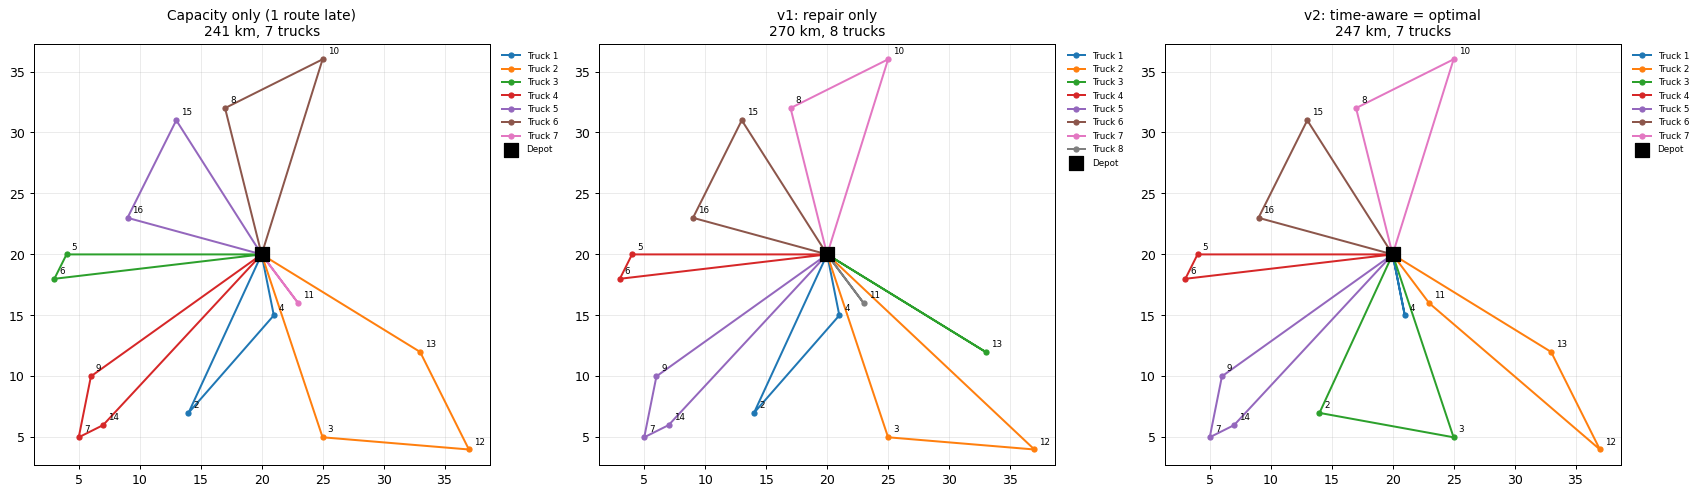

In [20]:
# เปรียบเทียบแผนที่: ก่อนใส่กติกาเวลา -> ซ่อมอย่างเดียว (v1) -> ปรับปรุงแบบรู้เวลา (v2)
inst = ctx["inst"]
fig, axes = plt.subplots(1, 3, figsize=(19, 5.6))
for ax, (key, label) in zip(axes, [("capacity_only", "Capacity only (1 route late)"),
                                   ("repair_v1", "v1: repair only"),
                                   ("time_aware_v2", "v2: time-aware = optimal")]):
    r = case.stages[key]
    plot_routes(inst, r, f"{label}\n{total_length(r, dist)} km, {len(r)} trucks", ax)
fig.tight_layout()
plt.show()

**อ่านผล**
- ดูแค่ความจุ → 241 กม. ดูดีบนกระดาษ แต่มี 1 เส้นทางถึงไซต์นาทีที่ 94 → **คอนกรีตเสีย ใช้จริงไม่ได้**
- ซ่อมอย่างเดียว (v1) → 270 กม. 8 คัน ผ่านกติกา แต่จุด 11 กับ 13 ถูกแยกไปคนละคันโดยไม่จำเป็น
- ปรับปรุงแบบรู้เวลา (v2) → **247 กม. 7 คัน = เท่ากับคำตอบที่ดีที่สุด** (รวม 11 → 12 → 13 ในคันเดียว)
- สรุป: กติกาความสด "แพง" แค่ **+6 กม. และไม่ต้องเพิ่มรถ** ถ้า Solver ฉลาดพอ

### 2.9 Sensitivity — ถ้านิยาม 90 นาทีเข้มขึ้น?
เช่น นับตั้งแต่เริ่มโหลดคอนกรีต (+10 นาที) จนเทเสร็จที่ไซต์สุดท้าย (+10 นาที) → เวลาไปถึงไซต์ต้องไม่เกิน **70 นาที**

In [21]:
cap_rule = capacity_check(inst)
start = improve(clarke_wright_savings(inst, dist, cap_rule), dist, cap_rule)

print(f"{'Arrival limit':<15}{'Solver km':>10}{'trucks':>8}{'Exact km':>10}{'trucks':>8}{'Gap %':>8}")
for test_limit in (90, 80, 70, 60):
    rule = freshness_check(inst, dist, test_limit, spd, svc)
    r = repair_split(start, inst.depot_id, dist, test_limit, spd, svc)
    r = improve([two_opt(x, dist, rule) for x in r], dist, rule)
    ex = exact_small(inst, dist, rule, inst.num_vehicles)
    km = total_length(r, dist)
    print(f"{test_limit:<15}{km:>10}{len(r):>8}{ex[0]:>10}{len(ex[1]):>8}{compute_gap(km, ex[0]):>8.2f}")

Arrival limit   Solver km  trucks  Exact km  trucks   Gap %
90                    247       7       247       7    0.00
80                    248       7       248       7    0.00
70                    258       7       248       7    4.03
60                    289       8       277       8    4.33


**อ่านผล:** ถึงนิยามจะเข้มขึ้นถึง 70 นาที ก็ยังใช้รถ 7 คันได้ แต่เมื่อเวลาตึงมาก การย้ายทีละจุดเริ่มห่างจากคำตอบที่ดีที่สุด (~4%) → ควรพัฒนาต่อด้วยการย้ายเป็นกลุ่มหรือ metaheuristic

---
# สรุป

### ผลลัพธ์
| | ระยะทาง | รถ | Gap | Feasible |
|---|---|---|---|---|
| A-n32-k5 | 827 | 5 | 5.48% | YES |
| B-n31-k5 | 677 | 5 | 0.74% | YES |
| P-n40-k5 | 514 | 5 | 12.23% | YES |
| **CPAC (freshness 90 นาที)** | **247 กม.** | **7 / 8** | **0.00%** (เทียบ exact optimum) | **YES (6 กติกา)** |

### สิ่งที่เรียนรู้
1. **Feasibility มาก่อน** — คำตอบที่สั้นที่สุด (241 กม.) ใช้จริงไม่ได้ถ้าคอนกรีตเสีย
2. **Feasible ยังไม่พอ ต้องวัดคุณภาพ** — แผน v1 ผ่านกติกาแต่แพงกว่า optimal 9.3%; การวัดกับ exact optimum ทำให้เจอปัญหาและแก้เป็น v2
3. **Solver ตัวเดียวใช้ได้จริง** — กติกาใหม่เพิ่มผ่าน `route_ok` จุดเดียว ไม่ต้องแก้ Solver และผล Mission 2 ไม่เปลี่ยน

### สมมติฐาน
- พิกัด/Demand ของเคส CPAC เป็นข้อมูลจำลองเพื่อการเรียนรู้; ระยะทาง EUC_2D ปัดเป็นกม.
- ความเร็ว 30 กม./ชม., เวลาเท 10 นาที/ไซต์, นับเวลาจากรถออกจากโรงงานถึงเวลาที่ไปถึงไซต์
- รถ 1 คันแวะได้หลายไซต์ (สมมติเป็นงานเทขนาดเล็ก)
- CO2 = กม. × 0.35 ลิตร/กม. × 2.68 kg CO2/ลิตร

### แนวทางพัฒนาต่อ
Multi-start / Simulated Annealing (หนีหลุมคำตอบ) · Or-opt ย้ายเป็นกลุ่ม · 2-opt* ข้ามคัน · ระยะถนนจริง + จราจร (OR-Tools) · Time window ของแต่ละไซต์ + แบ่งส่ง